In [1]:
config_dir = "/Users/sophiali/Desktop/chip-stroma-analysis/configs/local"

In [2]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

os.chdir(Path.cwd().parent)

from chip_stroma.utils.config import load_configs
from chip_stroma.utils.io import (
    sanitize_names, 
    save_name_mapping,
    build_patch_manifest,
    save_patch_manifest
)
from chip_stroma.data.preprocessing import (
    apply_tissue_filter,
    apply_artifact_filter,
    fit_normalizer,
    normalize_patches
)

logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

In [3]:
def log_header(config_path):
    logger.info("=" * 60)
    logger.info("Starting Pipeline Execution")
    logger.info("- Pipeline Stage: Preprocessing")
    logger.info(f"- Configurations: {config_path}")
    logger.info(f"- Working Directory: {Path.cwd()}")
    logger.info(f"- Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}")
    logger.info("=" * 60)

def log_footer(cfg):
    logger.info("=" * 60)
    logger.info("Successfully Completed Pipeline Execution")
    logger.info(f"- Patch Directory: {cfg.processed_data.patch_dir}")
    logger.info(f"- Mask Directory: {cfg.processed_data.mask_dir}")
    logger.info(f"- Name Mapping: {cfg.metadata.name_mapping}")
    logger.info(f"- Patch Manifest: {cfg.metadata.patch_manifeset}")
    logger.info(f"- Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}")
    logger.info("=" * 60)

In [4]:
log_header(config_path = Path(config_dir) / "preprocess.yaml")

config = load_configs(
    pipeline = Path(config_dir) / "preprocess.yaml",
    paths    = Path(config_dir) / "paths.yaml"
)

|2026-06-11|18:04:27.440| [INFO] ============================================================
|2026-06-11|18:04:27.440| [INFO] Starting Pipeline Execution
|2026-06-11|18:04:27.440| [INFO] - Pipeline Stage: Preprocessing
|2026-06-11|18:04:27.441| [INFO] - Configurations: /Users/sophiali/Desktop/chip-stroma-analysis/configs/local/preprocess.yaml
|2026-06-11|18:04:27.441| [INFO] - Working Directory: /Users/sophiali/Desktop/chip-stroma-analysis
|2026-06-11|18:04:27.441| [INFO] - Timestamp: 2026-06-11 18:04:27
|2026-06-11|18:04:27.442| [INFO] ============================================================
|2026-06-11|18:04:27.442| [INFO] ==================================================
|2026-06-11|18:04:27.442| [INFO] Step 01: Configurations
|2026-06-11|18:04:27.442| [INFO] - Pipeline: /Users/sophiali/Desktop/chip-stroma-analysis/configs/local/preprocess.yaml
|2026-06-11|18:04:27.443| [INFO] - Paths: /Users/sophiali/Desktop/chip-stroma-analysis/configs/local/paths.yaml
|2026-06-11|18:04:27.4

In [5]:
# 1. Sanitize sample folder names
name_mapping = sanitize_names(src_dir = config.paths.raw_data.patch_dir)

# Initialize a patch manifest to log filtering and mapping
manifest = build_patch_manifest(
    src_dir      = config.paths.raw_data.patch_dir,
    name_mapping = name_mapping
)


|2026-06-11|18:04:34.073| [INFO] ==================================================
|2026-06-11|18:04:34.074| [INFO] Step 02: Name Sanitization
|2026-06-11|18:04:34.074| [INFO] - Source Directory: /Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches
|2026-06-11|18:04:34.074| [INFO] --------------------------------------------------
|2026-06-11|18:04:34.075| [INFO] Sanitized 2 sample IDs
|2026-06-11|18:04:34.075| [INFO] ==================================================
|2026-06-11|18:04:34.076| [INFO] ==================================================
|2026-06-11|18:04:34.076| [INFO] Step 03: Patch Manifest
|2026-06-11|18:04:34.076| [INFO] - Source Directory: /Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches
|2026-06-11|18:04:34.076| [INFO] --------------------------------------------------
|2026-06-11|18:04:34.079| [INFO] Initialized manifest for 2 samples
|2026-06-11|18:04:34.079| [INFO] Populated manifest with 220 total patches
|2026-06-11|18:04:34.079| [INFO] =

In [6]:
# 4. Detect tissue and remove background
tissue_detection_cfg = config.preprocess.tissue_detection
manifest = apply_tissue_filter(
    src_dir           = config.paths.raw_data.patch_dir,
    manifest          = manifest,
    tissue_threshold  = tissue_detection_cfg.tissue_threshold,
    gaussian_sigma    = tissue_detection_cfg.gaussian_sigma,
    min_region_size   = tissue_detection_cfg.min_region_size,
    morph_disk_radius = tissue_detection_cfg.morph_disk_radius,
    haem_min_signal   = tissue_detection_cfg.haem_min_signal,
    dab_min_signal    = tissue_detection_cfg.dab_min_signal
)

|2026-06-11|18:04:35.957| [INFO] ==================================================
|2026-06-11|18:04:35.958| [INFO] Step 04: Tissue Detection
|2026-06-11|18:04:35.958| [INFO] - Tissue Threshold: 0.25
|2026-06-11|18:04:35.958| [INFO] - Gaussian Sigma: 1.0
|2026-06-11|18:04:35.959| [INFO] - Minimum Region Size: 500
|2026-06-11|18:04:35.959| [INFO] - Morphological Disk Radius: 3
|2026-06-11|18:04:35.960| [INFO] - Haematoxylin Minimum Signal: 0.13
|2026-06-11|18:04:35.960| [INFO] - DAB Minimum Signal: 0.05
|2026-06-11|18:04:35.960| [INFO] --------------------------------------------------


Tissue Detection: 100%|██████████| 220/220 [00:03<00:00, 67.81it/s]

|2026-06-11|18:04:39.222| [INFO] Evaluated 220 total patches: 
|2026-06-11|18:04:39.223| [INFO] - Passed Tissue Filter: 6 patches (2.7%)
|2026-06-11|18:04:39.223| [INFO] - Failed Haematoxylin Minimum: 191 patches (86.8%)
|2026-06-11|18:04:39.223| [INFO] - Failed Threshold: 23 patches (10.5%)
|2026-06-11|18:04:39.224| [INFO] ==================================================


In [7]:
test = manifest[manifest['passes_tissue'] == False]
test[test['tissue_ratio'] != -1]

,sample_id,original_id,patch,passes_tissue,passes_artifacts,include,tissue_ratio,lap_variance,dark_ratio,pen_ratio
45,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12041_raw.png,False,None,False,0.045212,None,None,None
49,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12045_raw.png,False,None,False,0.024796,None,None,None
53,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12049_raw.png,False,None,False,0.033905,None,None,None
55,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12050_raw.png,False,None,False,0.061569,None,None,None
56,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12051_raw.png,False,None,False,0.019943,None,None,None
103,T25-415_A1-2_H-BMO-77_SMA,T25-415 A1-2 H-BMO-77 SMA,tile_12094_raw.png,False,None,False,0.035034,None,None,None
113,T25-415_A6-2_H-BMO-73_SMA,T25-415 A6-2 H-BMO-73 SMA,tile_12003_raw.png,False,None,False,0.039383,None,None,None
114,T25-415_A6-2_H-BMO-73_SMA,T25-415 A6-2 H-BMO-73 SMA,tile_12004_raw.png,False,None,False,0.060242,None,None,None
116,T25-415_A6-2_H-BMO-73_SMA,T25-415 A6-2 H-BMO-73 SMA,tile_12006_raw.png,False,None,False,0.000000,None,None,None
119,T25-415_A6-2_H-BMO-73_SMA,T25-415 A6-2 H-BMO-73 SMA,tile_12009_raw.png,False,None,False,0.022858,None,None,None


In [ ]:
# 3. Detect artifacts and discard corrupted patches
artifact_detection_cfg = config.preprocess.artifact_detection
manifest = apply_artifact_filter(
    src_dir  = config.paths.raw_data.patch_dir,
    manifest = manifest,
    blur_threshold = artifact_detection_cfg.blur_threshold,
    dark_pixel_threshold = artifact_detection_cfg.dark_pixel_threshold,
    dark_pixel_ratio = artifact_detection_cfg.dark_pixel_ratio,
    pen_pixel_ratio = artifact_detection_cfg.pen_pixel_ratio
)

## Computing Haematoxylin minimum signal

In [ ]:
# Calibrate channel minimums
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from skimage.color import separate_stains, hdx_from_rgb

def calibrate_min_signal_thresholds(
    background_patches: list[Path],
    tissue_patches:     list[Path],
    percentile:         float = 99.0
) -> dict:
    """
    Calibrate minimum raw signal thresholds for haematoxylin and DAB channels
    by comparing raw max values across known background and tissue patches.

    Strategy:
    - Compute raw (pre-normalisation) max of each channel per patch
    - For background: the threshold must be ABOVE the percentile of their maxes
    - For tissue: the threshold must be BELOW the minimum of their maxes
    - Reports the gap between the two to confirm separability

    Parameters
    ----------
    background_patches : list[Path]
        Paths to known background patches.
    tissue_patches : list[Path]
        Paths to known tissue patches.
    percentile : float
        Percentile of background max values to use as threshold upper bound.
        Default 99.0 — threshold must exceed this to gate out all background.

    Returns
    -------
    dict
        Suggested thresholds and diagnostic statistics.
    """
    def extract_raw_maxes(paths: list[Path]) -> pd.DataFrame:
        records = []
        for path in paths:
            patch  = np.array(Image.open(path).convert("RGB"))
            stains = separate_stains(patch / 255.0, hdx_from_rgb)
            haem   = np.clip(stains[:, :, 0], 0, None)
            dab    = np.clip(stains[:, :, 1], 0, None)
            records.append({
                'patch':    path.name,
                'haem_max': haem.max(),
                'dab_max':  dab.max(),
                'haem_std': haem.std(),
                'dab_std':  dab.std(),
            })
        return pd.DataFrame(records)

    print("Extracting background patch statistics...")
    bg_df = extract_raw_maxes(background_patches)

    print("Extracting tissue patch statistics...")
    tissue_df = extract_raw_maxes(tissue_patches)

    # Compute suggested thresholds from background percentile
    haem_threshold = np.percentile(bg_df['haem_max'], percentile)
    dab_threshold  = np.percentile(bg_df['dab_max'],  percentile)

    # Diagnostic: confirm tissue patches clear the threshold
    haem_tissue_min = tissue_df['haem_max'].min()
    dab_tissue_min  = tissue_df['dab_max'].min()

    print("\n--- Haematoxylin Channel ---")
    print(f"  Background max  — mean: {bg_df['haem_max'].mean():.4f}, "
          f"p{percentile:.0f}: {haem_threshold:.4f}")
    print(f"  Tissue max      — mean: {tissue_df['haem_max'].mean():.4f}, "
          f"min: {haem_tissue_min:.4f}")
    print(f"  Suggested threshold: {haem_threshold:.4f}")
    print(f"  Gap (tissue min - threshold): "
          f"{haem_tissue_min - haem_threshold:.4f} "
          f"{'✓ separable' if haem_tissue_min > haem_threshold else '✗ NOT separable'}")

    print("\n--- DAB Channel ---")
    print(f"  Background max  — mean: {bg_df['dab_max'].mean():.4f}, "
          f"p{percentile:.0f}: {dab_threshold:.4f}")
    print(f"  Tissue max      — mean: {tissue_df['dab_max'].mean():.4f}, "
          f"min: {dab_tissue_min:.4f}")
    print(f"  Suggested threshold: {dab_threshold:.4f}")
    print(f"  Gap (tissue min - threshold): "
          f"{dab_tissue_min - dab_threshold:.4f} "
          f"{'✓ separable' if dab_tissue_min > dab_threshold else '✗ NOT separable'}")

    print("\n--- Background Stats ---")
    print(bg_df[['haem_max', 'dab_max', 'haem_std', 'dab_std']].describe())

    print("\n--- Tissue Stats ---")
    print(tissue_df[['haem_max', 'dab_max', 'haem_std', 'dab_std']].describe())

    return {
        'haem_min_signal': round(haem_threshold, 4),
        'dab_min_signal':  round(dab_threshold,  4),
        'bg_stats':        bg_df,
        'tissue_stats':    tissue_df,
    }

In [ ]:
background_patches = [
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12092_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12000_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12042_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12072_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12088_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12089_raw.png")
]

tissue_patches = [
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12041_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12003_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12016_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12040_raw.png"),
    Path("/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12043_raw.png")
]

results = calibrate_min_signal_thresholds(background_patches, tissue_patches)

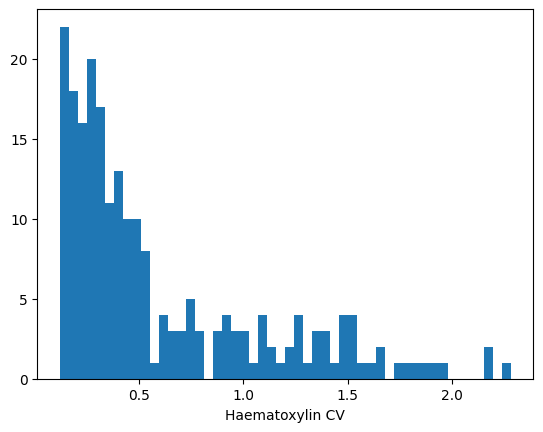

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.color import separate_stains, hdx_from_rgb

src_dir = config.paths.raw_data.patch_dir

haem_cvs = []
for _, row in manifest.iterrows():
    patch  = np.array(Image.open(src_dir / row['original_id'] / row['patch']).convert("RGB"))
    stains = separate_stains(patch / 255.0, hdx_from_rgb)
    haem   = np.clip(stains[:, :, 0], 0, None)
    haem_cvs.append(haem.std() / (haem.mean() + 1e-8))

plt.hist(haem_cvs, bins=50)
plt.xlabel("Haematoxylin CV")
plt.show()

In [ ]:
HAEM_MIN_SIGNAL = 0.13
DAB_MIN_SIGNAL = 0.05

def test_tissue(sample_path,
                tissue_threshold: float = 0.5,
                gaussian_sigma: float = 1.0,
                min_region_size: int = 500,
                morph_disk_radius: int = 3):
    # Diagnose if blue and brown is sufficient for Otsu's

    from PIL import Image
    from skimage.color import separate_stains, hdx_from_rgb
    import numpy as np
    from scipy.ndimage import binary_fill_holes
    from skimage.filters import threshold_otsu, gaussian
    from skimage.morphology import (
        remove_small_objects, 
        remove_small_holes, 
        closing,
        opening,
        disk,
        dilation
    )

    patch = np.array(Image.open(sample_path).convert("RGB"))
    stains = separate_stains(patch / 255.0, hdx_from_rgb)
    haem_raw = np.clip(stains[:, :, 0], 0, None)
    dab_raw = np.clip(stains[:, :, 1], 0, None)

    if haem_raw.max() <= HAEM_MIN_SIGNAL: 
        print("Haematoxylin min signal not reached")
        return

    # Scale the haematoxylin channel to [0-1]
    haem = ((haem_raw - haem_raw.min()) 
            / (haem_raw.max() - haem_raw.min() + 1e-8))
    
    # Gaussian smoothing before thresholding
    haem_smoothed = gaussian(haem, sigma = gaussian_sigma)

    # Compute Otsu threshold per channel to segment for tissue
    try: haem_thresh = threshold_otsu(haem_smoothed)
    except ValueError: haem_thresh = None

    # Build per-channel masks and use both to detect for tissue
    haem_mask = haem_smoothed > haem_thresh if haem_thresh is not None \
                else np.zeros(haem.shape, dtype = bool)

    # Build the DAB channel mask if haematoxylin signal was confirmed
    dab = ((dab_raw - dab_raw.min())
        / (dab_raw.max() - dab_raw.min() + 1e-8))
    dab_smoothed = gaussian(dab, sigma = gaussian_sigma)
    dab_mask = dab_smoothed > threshold_otsu(dab_smoothed)
    # if dab_raw.max() > DAB_MIN_SIGNAL:
        # dab = ((dab_raw - dab_raw.min())
        #     / (dab_raw.max() - dab_raw.min() + 1e-8))
        # dab_smoothed = gaussian(dab, sigma = gaussian_sigma)
        # dab_mask = dab_smoothed > threshold_otsu(dab_smoothed)
    # else:
    #     dab_mask = np.zeros(haem_mask.shape, dtype = bool)

    # DAB fills regions that haematoxylin misses
    tissue_mask = haem_mask | dab_mask
    
    # Perform morphological cleanup upon the tissue mask
    tissue_mask = dilation(tissue_mask, disk(morph_disk_radius * 1.25))

    selem       = disk(morph_disk_radius)
    tissue_mask = opening(tissue_mask, selem)
    tissue_mask = closing(tissue_mask, selem)

    # Remove small connected components for area filtering
    tissue_mask = remove_small_objects(
        tissue_mask, 
        max_size = min_region_size - 1
    )
    tissue_mask = remove_small_holes(
        tissue_mask, 
        max_size = min_region_size - 1
    )

    print(f"Tissue Content: {tissue_mask.mean()}")
    print(f"haem range: {haem.min():.3f} to {haem.max():.3f}, std: {haem.std():.3f}")

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(patch); axes[0].set_title('raw')
    axes[1].imshow(haem, cmap='gray'); axes[1].set_title('haem')
    axes[2].imshow(dab, cmap='gray'); axes[2].set_title('dab')
    axes[3].imshow(tissue_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(haem_raw, cmap='gray'); axes[0].set_title('raw')
    axes[1].imshow(haem, cmap='gray'); axes[1].set_title('normalized')
    axes[2].imshow(haem_smoothed, cmap='gray'); axes[2].set_title('smoothed')
    axes[3].imshow(haem_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(dab_raw, cmap='gray'); axes[0].set_title('raw')
    axes[1].imshow(dab, cmap='gray'); axes[1].set_title('normalized')
    axes[2].imshow(dab_smoothed, cmap='gray'); axes[2].set_title('smoothed')
    axes[3].imshow(dab_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()


In [ ]:
sample_path = "/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12041_raw.png"

test_tissue(sample_path)

In [ ]:
sample_path = "/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A6-2 H-BMO-73 SMA/tile_12003_raw.png"

test_tissue(sample_path)

In [8]:
HAEM_MIN_SIGNAL = 0.13
DAB_MIN_SIGNAL = 0.05

def test_tissue_1(sample_path,
                tissue_threshold: float = 0.5,
                gaussian_sigma: float = 1.0,
                min_region_size: int = 500,
                morph_disk_radius: int = 3):
    # Diagnose if blue and brown is sufficient for Otsu's

    from PIL import Image
    from skimage.color import separate_stains, hdx_from_rgb
    import numpy as np
    from scipy.ndimage import binary_fill_holes
    from skimage.filters import threshold_otsu, gaussian
    from skimage.morphology import (
        remove_small_objects, 
        remove_small_holes, 
        closing,
        opening,
        disk,
        dilation
    )

    patch = np.array(Image.open(sample_path).convert("RGB"))
    stains = separate_stains(patch / 255.0, hdx_from_rgb)
    haem_raw = np.clip(stains[:, :, 0], 0, None)
    dab_raw = np.clip(stains[:, :, 1], 0, None)

    if haem_raw.max() <= HAEM_MIN_SIGNAL: 
        print("Haematoxylin min signal not reached")
        return
    
    haem_mask = np.zeros(haem_raw.shape, dtype = bool)
    dab_mask  = np.zeros(dab_raw.shape, dtype = bool)

    # Scale the haematoxylin channel to [0-1]
    haem = ((haem_raw - haem_raw.min()) 
            / (haem_raw.max() - haem_raw.min() + 1e-8))
    dab  = ((dab_raw - dab_raw.min()) 
            / (dab_raw.max() - dab_raw.min() + 1e-8))
    
    # Gaussian smoothing before thresholding
    haem_smoothed = gaussian(haem, sigma = gaussian_sigma)
    dab_smoothed  = gaussian(dab, sigma = gaussian_sigma)

    # Compute Otsu threshold per channel to segment for tissue
    haem_mask = haem_smoothed > threshold_otsu(haem_smoothed)

    # Only use DAB if it passes the threshold
    if dab_raw.max() > DAB_MIN_SIGNAL:
        dab_mask = dab_smoothed > threshold_otsu(dab_smoothed)
    else:
        print("DAB min. signal not met")

    # DAB fills regions that haematoxylin misses
    tissue_mask = haem_mask | dab_mask
    
    # Perform morphological cleanup upon the tissue mask
    tissue_mask = dilation(tissue_mask, disk(morph_disk_radius * 1.25))

    selem       = disk(morph_disk_radius)
    tissue_mask = opening(tissue_mask, selem)
    tissue_mask = closing(tissue_mask, selem)

    # Remove small connected components for area filtering
    tissue_mask = remove_small_objects(
        tissue_mask, 
        max_size = min_region_size - 1
    )
    tissue_mask = remove_small_holes(
        tissue_mask, 
        max_size = min_region_size - 1
    )

    print(f"Tissue Content: {tissue_mask.mean()}")
    print(f"haem range: {haem.min():.3f} to {haem.max():.3f}, std: {haem.std():.3f}")

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(patch); axes[0].set_title('raw')
    axes[1].imshow(haem, cmap='gray'); axes[1].set_title('haem')
    axes[2].imshow(dab, cmap='gray'); axes[2].set_title('dab')
    axes[3].imshow(tissue_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(haem_raw, cmap='gray'); axes[0].set_title('raw')
    axes[1].imshow(haem, cmap='gray'); axes[1].set_title('normalized')
    axes[2].imshow(haem_smoothed, cmap='gray'); axes[2].set_title('smoothed')
    axes[3].imshow(haem_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(dab_raw, cmap='gray'); axes[0].set_title('raw')
    axes[1].imshow(dab, cmap='gray'); axes[1].set_title('normalized')
    axes[2].imshow(dab_smoothed, cmap='gray'); axes[2].set_title('smoothed')
    axes[3].imshow(dab_mask, cmap='gray'); axes[3].set_title('mask')
    plt.show()


In [ ]:
sample_path = "/Users/sophiali/Desktop/chip-stroma-analysis/data/raw/patches/T25-415 A1-2 H-BMO-77 SMA/tile_12016_raw.png"
test_tissue_1(sample_path)